# AI + GenAI Healthcare Intelligence Platform
## Predicting Readmission Risk & Generating Insights

In [1]:
import pandas as pd
df = pd.read_csv("hospital_data.csv")
df.head()


,provider_ccn,hospital_name,city,state,total_discharges,number_of_beds,hospital_number_of_beds_for_adults_and_peds,bed_days_available,fte_employees,interns_residents,...,inpatient_charges,outpatient_charges,net_patient_revenue,total_operating_expense,net_income,cost_per_discharges,revenue_efficiency,profit_margin,bed_utilization,staff_efficiency
0,110130,IRWIN COUNTY HOSPITAL,OCILLA,GA,77,64,34.0,2108,97.15,0.0,...,1892400,3881115,1557790,3033643,-1248820,31993.012990,20231.038960,-80.17%,1.203125,0.792589
1,144042,LAKE BEHAVIORAL HOSPITAL,WAUKEGAN,IL,1057,161,161.0,14812,227.95,0.0,...,22372700,960619,9784298,8585822,2632879,7674.041627,9256.667928,26.91%,6.565217,4.636982
2,43036,EVEREST REHABILITATION HOSPITAL BENT,ROGERS,AR,63,36,36.0,2124,74.54,0.0,...,2948357,34172,1450453,2447938,-518505,44372.063490,23023.063490,-35.75%,1.750000,0.845184
3,454155,OCEANS BEHAVIORAL HOSPITAL CORPUS CH,CORPUS CHRISTI,TX,137,42,42.0,1890,68.01,0.0,...,1703505,0,1261761,3445228,-2183297,14348.145990,9209.934307,-173.04%,3.261905,2.014410
4,421303,WILLIAMSBURG REGIONAL HOSPITAL,KINGSTREE,SC,90,25,21.0,2289,181.03,0.0,...,3388938,10205503,5422988,8676352,-3260557,83372.811110,60255.422220,-60.12%,3.600000,0.497155


In [2]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'data_pipeline.ipynb', 'final_dataset_with_predictions.csv', 'healthcare_analysis.ipynb', 'hospital_data.csv', 'readmission_model.pkl']


In [3]:
df['readmission_risk'] = (df['net_income'] < df['net_income'].median()).astype(int)
df.head()

,provider_ccn,hospital_name,city,state,total_discharges,number_of_beds,hospital_number_of_beds_for_adults_and_peds,bed_days_available,fte_employees,interns_residents,...,outpatient_charges,net_patient_revenue,total_operating_expense,net_income,cost_per_discharges,revenue_efficiency,profit_margin,bed_utilization,staff_efficiency,readmission_risk
0,110130,IRWIN COUNTY HOSPITAL,OCILLA,GA,77,64,34.0,2108,97.15,0.0,...,3881115,1557790,3033643,-1248820,31993.012990,20231.038960,-80.17%,1.203125,0.792589,1
1,144042,LAKE BEHAVIORAL HOSPITAL,WAUKEGAN,IL,1057,161,161.0,14812,227.95,0.0,...,960619,9784298,8585822,2632879,7674.041627,9256.667928,26.91%,6.565217,4.636982,0
2,43036,EVEREST REHABILITATION HOSPITAL BENT,ROGERS,AR,63,36,36.0,2124,74.54,0.0,...,34172,1450453,2447938,-518505,44372.063490,23023.063490,-35.75%,1.750000,0.845184,1
3,454155,OCEANS BEHAVIORAL HOSPITAL CORPUS CH,CORPUS CHRISTI,TX,137,42,42.0,1890,68.01,0.0,...,0,1261761,3445228,-2183297,14348.145990,9209.934307,-173.04%,3.261905,2.014410,1
4,421303,WILLIAMSBURG REGIONAL HOSPITAL,KINGSTREE,SC,90,25,21.0,2289,181.03,0.0,...,10205503,5422988,8676352,-3260557,83372.811110,60255.422220,-60.12%,3.600000,0.497155,1


In [4]:
features = df.select_dtypes(include=['int64','float64']).drop(columns=['readmission_risk'],errors='ignore')
X = features
Y = df['readmission_risk']

In [5]:
!pip install scikit-learn

In [6]:
features = df.select_dtypes(include=['int64', 'float64']).drop(columns=['readmission_risk'], errors='ignore')

X = features
y = df['readmission_risk']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [9]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [10]:
import pandas as pd

importance = model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(10)

,Feature,Importance
12,net_income,0.788226
10,net_patient_revenue,0.054958
9,outpatient_charges,0.044154
15,bed_utilization,0.019924
11,total_operating_expense,0.017796
5,fte_employees,0.011388
1,total_discharges,0.010491
8,inpatient_charges,0.008659
7,total_costs,0.008096
14,revenue_efficiency,0.007909


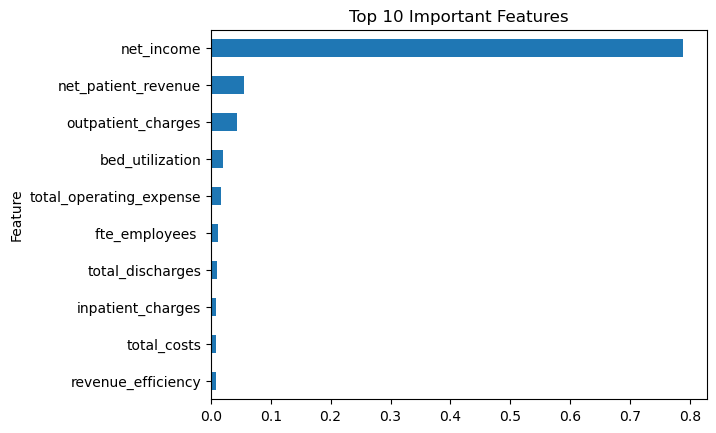

In [11]:
import matplotlib.pyplot as plt

feature_importance_df.head(10).plot(
    kind='barh',
    x='Feature',
    y='Importance',
    legend=False
)

plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

In [12]:
def explain_risk(row):
    reasons = []
    
    if row['net_income'] < 0:
        reasons.append("Low net income")
        
    if row['total_costs'] > 500000:
        reasons.append("High operational costs")
        
    if row['bed_utilization'] > 80:
        reasons.append("High bed utilization")
        
    return ", ".join(reasons)

df['risk_explanation'] = df.apply(explain_risk, axis=1)

df[['hospital_name', 'readmission_risk', 'risk_explanation']].head()

,hospital_name,readmission_risk,risk_explanation
0,IRWIN COUNTY HOSPITAL,1,"Low net income, High operational costs"
1,LAKE BEHAVIORAL HOSPITAL,0,High operational costs
2,EVEREST REHABILITATION HOSPITAL BENT,1,"Low net income, High operational costs"
3,OCEANS BEHAVIORAL HOSPITAL CORPUS CH,1,"Low net income, High operational costs"
4,WILLIAMSBURG REGIONAL HOSPITAL,1,"Low net income, High operational costs"


In [13]:
def explain_risk_advanced(row):
    if row['net_income'] < 0:
        return "Hospital is high risk due to financial losses and high operational burden."
    elif row['bed_utilization'] > 80:
        return "Hospital is under pressure due to high patient load."
    else:
        return "Hospital is operating under stable conditions."

df['ai_summary'] = df.apply(explain_risk_advanced, axis=1)

In [14]:
import joblib

joblib.dump(model, "readmission_model.pkl")
df.to_csv("final_dataset_with_predictions.csv", index=False)

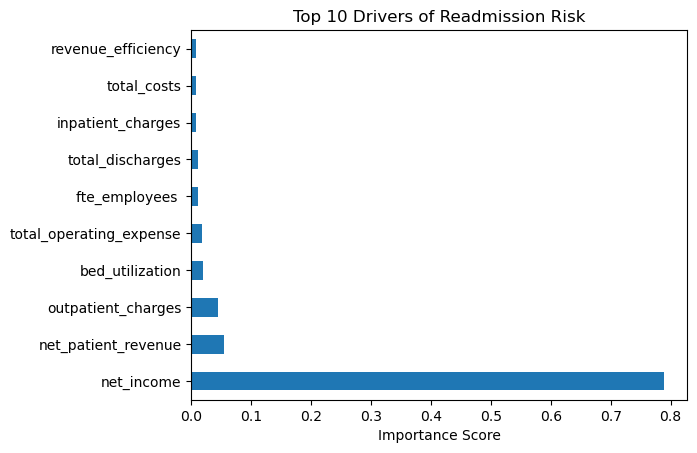

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.nlargest(10).plot(kind='barh')

plt.title("Top 10 Drivers of Readmission Risk")
plt.xlabel("Importance Score")
plt.show()